# Plant segmentation v2 - absolute-intensity threshold + fixed-rig priors

Segments the bolting plant from the fixed-camera NIR timelapse and measures stem height per frame.

**Why intensity, not edges or background subtraction:** the plant is *bright* against a dark background in NIR, so an intensity threshold isolates it in one step. Edge detection fires on the rail/clamp/cable too. Temporal *background subtraction* fails here for the opposite reason - the lower leaves and stem sit in the same spot every frame, so they get absorbed into the background and subtracted away, leaving only the newly-grown top. We therefore threshold the absolute-scaled intensity directly.

**Day/night robustness:** frames are scaled to 8-bit with the sensor's **absolute** range (12-bit, 0-4095), not per-frame min/max, and the per-frame threshold is `mean + K_SIGMA * sigma` of the *quiet* (background) part of the ROI. This tracks illumination automatically and avoids Otsu's failure on low-contrast night frames.

**Hardware rejection:** dark hardware is excluded for free by the threshold; the only bright hardware (the thin horizontal rail) is removed by **shape**; the `ROI` crops out the top cable and side clamp; and **connectivity** (anchor on the largest bright component, then bridge nearby leaves) reunites the plant while ignoring stray glints.

Pipeline: **Stage 0** index frames -> **Stage 1** calibrate rig (hardware mask + plant-free reference) -> **Stage 2** per-frame mask -> **Stage 3** stem height -> **Stage 4** batch + CSV + growth curve.

Run with the `microneedle (plant mask)` kernel.


In [ ]:
import re
import sys
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import matplotlib.pyplot as plt
from plantcv import plantcv as pcv
from skimage.morphology import reconstruction

pcv.params.debug = None
print("kernel:", sys.executable)
print("opencv:", cv2.__version__, "| plantcv:", pcv.__version__)

## Stage 0 - Setup & frame index

Set the timelapse folder and `FRAME_STEP` (process every Nth frame; `1` = all 325). `TUNING_INDEX` picks the frame used to tune Stages 1-3 - a mid-series frame shows a clear stem.

In [2]:
# --- Stage 0 params (edit here) ---
TIMELAPSE_DIR = Path(
    r"H:\My Drive\Work\DiSTAP\Research\Auxin IAA\IAA-MN longitudinal\IAA Nanosensor Experiment\In planta\Nb\Treatment_Control\Light_6to22\Temp_Hum_Variable\Run 4\DEV_1AB22C05B465\timelapse_2026-05-07_12-56-08"
)
FRAME_GLOB = "*.tif"
FRAME_STEP = 5       # process every Nth frame (1 = all 325)
TUNING_INDEX = 160   # frame (in full sorted list) used to tune Stages 1-3

In [ ]:
assert TIMELAPSE_DIR.exists(), f"Folder not found: {TIMELAPSE_DIR}"
all_paths = sorted(TIMELAPSE_DIR.glob(FRAME_GLOB))
assert all_paths, f"No frames matching {FRAME_GLOB} in {TIMELAPSE_DIR}"

REPO_ROOT = next((par for par in [Path.cwd(), *Path.cwd().parents]
                  if (par / "setup.py").exists()), Path.cwd())

_TS_RE = re.compile(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})")
def parse_timestamp(path):
    m = _TS_RE.search(path.name)
    return datetime.strptime(m.group(1), "%Y-%m-%d_%H-%M-%S") if m else None

timestamps = [parse_timestamp(p) for p in all_paths]
subset_paths = all_paths[::FRAME_STEP]

# Sensor max for absolute-range scaling. 12-bit camera => 4095. Overridden below from data.
SENSOR_MAX = 4095

def load_gray(path):
    g = cv2.imread(str(path), cv2.IMREAD_ANYDEPTH | cv2.IMREAD_GRAYSCALE)
    if g is None:
        raise ValueError(f"OpenCV could not read: {path}")
    return g

def to_u8(img):
    # per-frame min-max stretch - for DISPLAY only (distorts absolute brightness)
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

def raw_u8(img):
    # absolute-range 8-bit - comparable across frames (used for background subtraction)
    return np.clip(img.astype(np.float32) / SENSOR_MAX * 255.0, 0, 255).astype(np.uint8)

TUNING_INDEX = min(TUNING_INDEX, len(all_paths) - 1)
tuning_path = all_paths[TUNING_INDEX]
gray = load_gray(tuning_path)
gray_u8 = to_u8(gray)

print(f"repo root    : {REPO_ROOT}")
print(f"total frames : {len(all_paths)}")
print(f"subset (every {FRAME_STEP}) : {len(subset_paths)}")
print(f"first : {all_paths[0].name}  {timestamps[0]}")
print(f"last  : {all_paths[-1].name}  {timestamps[-1]}")
print(f"tuning: idx {TUNING_INDEX}  {tuning_path.name}  {timestamps[TUNING_INDEX]}")
print(f"shape : {gray.shape}  dtype {gray.dtype}  min {gray.min()} max {gray.max()}")

fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(gray_u8, cmap="gray")
ax.set_title(f"Tuning frame (idx {TUNING_INDEX}) - read ROI / base-line coords off the grid")
ax.set_xticks(np.arange(0, gray_u8.shape[1], 250))
ax.set_yticks(np.arange(0, gray_u8.shape[0], 250))
ax.grid(color="cyan", alpha=0.3, linewidth=0.5)
plt.show()


## Stage 1 - Fixed-rig calibration (compute once)

Two products from a temporal subset:

1. **`hardware_mask`** - removes **only static bright thin/horizontal structures (the rail)** plus any manual rectangles. We intersect "bright" with a "wide-horizontal, thin-vertical" shape test, so the compact plant base can never qualify. Stage 2 subtracts this.
2. **`background`** - per-pixel low percentile over time, shown only as a **plant-free reference** (it is *not* subtracted - see the intro). Handy for sanity-checking the rig and reading the soil line.

QC: the red hardware mask must **not** touch the plant.


In [ ]:
# --- Stage 1 params (edit here) ---
BG_SAMPLE_STEP = 20     # sample every Nth frame for the background/rail estimate
BG_DOWNSCALE = 2        # downscale factor for calibration (speed / memory)
BG_PCTILE = 20          # per-pixel percentile over time -> plant-free background (lower = safer)

RAIL_BRIGHT_PCT = 90    # "bright" cutoff = this percentile of the median image
RAIL_MIN_WIDTH = 81     # min horizontal run (full-res px) to count as rail
RAIL_MAX_HEIGHT = 25    # max vertical thickness (full-res px) for a rail band
RAIL_MIN_AREA = 400     # drop detected specks smaller than this (full-res px) -> cleaner mask

# Manual hardware exclusion rectangles, full-res (x0, y0, x1, y1). Empty = none.
# The probe body is dark and already removed by the Stage 2 threshold, so you usually do NOT
# need to box the whole probe. Only add a rectangle over its bright zone (cable / upper patch)
# if glints there leak into the plant - and keep the rectangle's BOTTOM edge ABOVE the plant's
# maximum reach in the last frame, or you will clip the apex and undercount height.
HARDWARE_RECTS = []     # e.g. [(1500, 60, 1950, 830)]  # top cable/patch zone only


In [ ]:
bg_paths = all_paths[::BG_SAMPLE_STEP]
_ds = max(1, int(BG_DOWNSCALE))

# Absolute-range stack so day/night are comparable and the background is meaningful.
stack = []
for p in bg_paths:
    g = load_gray(p)
    if _ds > 1:
        g = cv2.resize(g, (g.shape[1] // _ds, g.shape[0] // _ds), interpolation=cv2.INTER_AREA)
    stack.append(raw_u8(g))
stack = np.stack(stack)

H, W = gray.shape

# (1) Plant-free background: low per-pixel percentile over time, upscaled to full res.
bg_small = np.percentile(stack, BG_PCTILE, axis=0).astype(np.uint8)
background = cv2.resize(bg_small, (W, H), interpolation=cv2.INTER_LINEAR)
print(f"background from {len(bg_paths)} frames (p{BG_PCTILE}), shape {background.shape}")

# (2) Rail mask: bright + wide-horizontal + thin-vertical (shape test), from the median image.
median_bg_small = np.median(stack, axis=0).astype(np.uint8)
bright_t = np.percentile(median_bg_small, RAIL_BRIGHT_PCT)
static_bright = (median_bg_small > bright_t).astype(np.uint8) * 255

w_se = max(3, RAIL_MIN_WIDTH // _ds)
h_se = max(3, RAIL_MAX_HEIGHT // _ds)
horiz = cv2.morphologyEx(static_bright, cv2.MORPH_OPEN,
                         cv2.getStructuringElement(cv2.MORPH_RECT, (w_se, 1)))
compact = cv2.morphologyEx(static_bright, cv2.MORPH_OPEN,
                           cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (h_se, h_se)))
rail_small = cv2.bitwise_and(horiz, cv2.bitwise_not(compact))

_min_a = max(1, RAIL_MIN_AREA // (_ds * _ds))
_n, _lbl, _st, _ = cv2.connectedComponentsWithStats(rail_small, connectivity=8)
rail_small = np.zeros_like(rail_small)
for _l in range(1, _n):
    if int(_st[_l, cv2.CC_STAT_AREA]) >= _min_a:
        rail_small[_lbl == _l] = 255

rail_mask = cv2.resize(rail_small, (W, H), interpolation=cv2.INTER_NEAREST)
hardware_mask = rail_mask.copy()
for (x0, y0, x1, y1) in HARDWARE_RECTS:
    hardware_mask[y0:y1, x0:x1] = 255

print("hardware mask pixels:", int((hardware_mask > 0).sum()))

qc = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
qc[hardware_mask > 0] = (0, 0, 255)  # BGR red; shown correctly after BGR->RGB below
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes[0].imshow(background, cmap="gray"); axes[0].set_title(f"Background (p{BG_PCTILE}) - should be plant-free"); axes[0].axis("off")
axes[1].imshow(rail_mask, cmap="gray"); axes[1].set_title("Hardware / rail mask"); axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(qc, cv2.COLOR_BGR2RGB))
axes[2].set_title("Hardware (red) on frame - must miss the plant"); axes[2].axis("off")
plt.tight_layout(); plt.show()


## Stage 2 - Per-frame segmentation (hysteresis / reconstruction)

Per frame, in absolute-range 8-bit inside `ROI`:

1. Two background-relative levels from the quiet part of the ROI: a **high** threshold `mean + K_SIGMA*sigma` (confident bright leaves = the *seed*) and a **low** threshold `mean + K_SIGMA_LOW*sigma` (also catches the dim stem/petioles, plus some noise).
2. Subtract `hardware_mask`; drop everything below `BASE_LINE_Y` (bench glints).
3. Keep only sizable seed components, then **grow the seed into low-threshold pixels connected to it** (morphological reconstruction / hysteresis). This traces the *real* dim stem and petioles and reunites the plant **without inventing pixels** in dark gaps - so no petiole webbing and no solid column down to the pot.
4. Light edge smoothing, keep the largest component (attach any still-detached leaf within `BRIDGE_KSIZE`), area-limited hole fill.

Lower `K_SIGMA_LOW` to trace more of the stem (risk: noise creeps in); raise it if background starts to connect. `CLOSE_KSIZE` stays small on purpose - large closes web the petioles.


In [ ]:
# --- Stage 2 params (edit here) ---
# ROI crops to the plant column (full-res x0, y0, x1, y1). Excludes the top cable arc and the
# side clamp so they cannot leak in. Keep y0 ABOVE the apex in the last frame. None = full frame.
ROI = (250, 700, 1750, 2560)

# Soil/pot line (full-res y). The plant base is dim and often falls below threshold, so PIN this
# to the soil line (fixed camera => constant). Read it off the Stage 0 grid. None = auto.
BASE_LINE_Y = 2450

BLUR_KSIZE = 5          # pre-threshold denoise (odd)
K_SIGMA = 3.0           # HIGH threshold = mean + k*sigma of ROI background (confident plant "seed")
K_SIGMA_LOW = 2.0       # LOW threshold for hysteresis fill (lower => traces more dim stem/petiole)
OPEN_KSIZE = 5          # despeckle the seed
CLOSE_KSIZE = 15        # light edge smoothing only (keep small; large values web the petioles)
MAX_HOLE_AREA = 2000    # fill interior holes up to this many px
MIN_PLANT_AREA = 150    # drop bright specks / metal glints smaller than this
BRIDGE_KSIZE = 161      # attach any leaf still detached after reconstruction, within this gap (px)


In [ ]:
def _odd(k, m=3):
    k = max(m, int(k)); return k if k % 2 else k + 1

def _resolve_roi(shape, roi):
    h, w = shape
    if roi is None:
        return (0, 0, w, h)
    x0, y0, x1, y1 = roi
    return (max(0, x0), max(0, y0), min(w, x1), min(h, y1))

def segment_plant(gray_img, *, hardware_mask, roi=None, base_y=None,
                  blur=BLUR_KSIZE, k_sigma=K_SIGMA, k_sigma_low=K_SIGMA_LOW, open_k=OPEN_KSIZE,
                  close_k=CLOSE_KSIZE, max_hole_area=MAX_HOLE_AREA, min_area=MIN_PLANT_AREA,
                  bridge_k=BRIDGE_KSIZE):
    h, w = gray_img.shape
    x0, y0, x1, y1 = _resolve_roi(gray_img.shape, roi)

    # Absolute-range 8-bit so the threshold means the same thing day and night.
    base = raw_u8(gray_img)
    b = cv2.GaussianBlur(base, (_odd(blur), _odd(blur)), 0)
    sub = b[y0:y1, x0:x1]

    # Background-relative levels from the quiet (lower 80%) part of the ROI.
    quiet = sub[sub < np.percentile(sub, 80)]
    mu = float(quiet.mean()) if quiet.size else 0.0
    sd = float(quiet.std()) + 1e-6
    t_hi = int(np.clip(mu + k_sigma * sd, 1, 255))
    t_lo = int(np.clip(mu + k_sigma_low * sd, 1, 255))

    # HIGH mask = confident plant (bright leaves). LOW mask = also the dim stem/petioles + some noise.
    hi = np.zeros((h, w), np.uint8); hi[y0:y1, x0:x1] = (sub > t_hi).astype(np.uint8) * 255
    lo = np.zeros((h, w), np.uint8); lo[y0:y1, x0:x1] = (sub > t_lo).astype(np.uint8) * 255
    if hardware_mask is not None:
        hi[hardware_mask > 0] = 0; lo[hardware_mask > 0] = 0
    if base_y is not None:  # drop everything below the soil line (bench/shelf glints)
        hi[int(base_y):, :] = 0; lo[int(base_y):, :] = 0

    # Denoise the seed; keep only sizable seed components so noise cannot seed the fill.
    if open_k > 0:
        hi = cv2.morphologyEx(hi, cv2.MORPH_OPEN,
                              cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (_odd(open_k), _odd(open_k))))
    n, labels, stats, _ = cv2.connectedComponentsWithStats((hi > 0).astype(np.uint8), 8)
    seed = np.zeros((h, w), np.uint8)
    for lab in range(1, n):
        if int(stats[lab, cv2.CC_STAT_AREA]) >= min_area:
            seed[labels == lab] = 255

    if not seed.any():
        return np.zeros((h, w), np.uint8), (int(base_y) if base_y is not None else y1 - 1), t_hi

    # Hysteresis by morphological reconstruction: grow the seed ONLY into low-threshold pixels that
    # are actually connected to it. This traces the real (dim) stem and petioles and reunites the
    # plant, WITHOUT inventing pixels in dark gaps (no petiole webbing, no column to the pot).
    lo = cv2.bitwise_or(lo, seed)  # seed must be a subset of the mask
    rec = reconstruction((seed > 0).astype(np.uint8), (lo > 0).astype(np.uint8), method="dilation")
    m = (rec > 0).astype(np.uint8) * 255

    if close_k > 0:  # light edge smoothing only
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE,
                             cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (_odd(close_k), _odd(close_k))))

    # Keep the largest component, then attach any still-detached sizable leaf within bridge_k.
    n, labels, stats, _ = cv2.connectedComponentsWithStats((m > 0).astype(np.uint8), 8)
    valid = [lab for lab in range(1, n) if int(stats[lab, cv2.CC_STAT_AREA]) >= min_area]
    keep = np.zeros((h, w), np.uint8)
    if not valid:
        return keep, (int(base_y) if base_y is not None else y1 - 1), t_hi
    anchor = max(valid, key=lambda lab: int(stats[lab, cv2.CC_STAT_AREA]))
    keep[labels == anchor] = 255
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (_odd(bridge_k), _odd(bridge_k)))
    remaining = set(valid) - {anchor}
    changed = True
    while changed and remaining:
        changed = False
        reach = cv2.dilate(keep, se)
        for lab in list(remaining):
            if (reach[labels == lab] > 0).any():
                keep[labels == lab] = 255
                remaining.discard(lab)
                changed = True
    m = keep

    if base_y is None:
        ys = np.where(m > 0)[0]
        base_y_use = int(ys.max()) if ys.size else y1 - 1
    else:
        base_y_use = int(base_y)

    # area-limited interior hole fill (do not close petiole gaps)
    bg = (m == 0).astype(np.uint8)
    nb, lb, st, _ = cv2.connectedComponentsWithStats(bg, 8)
    for lab in range(1, nb):
        x = st[lab, cv2.CC_STAT_LEFT]; y = st[lab, cv2.CC_STAT_TOP]
        bw = st[lab, cv2.CC_STAT_WIDTH]; bh = st[lab, cv2.CC_STAT_HEIGHT]
        area = st[lab, cv2.CC_STAT_AREA]
        touches = x <= 0 or y <= 0 or (x + bw) >= w or (y + bh) >= h
        if not touches and area <= max_hole_area:
            m[lb == lab] = 255

    return m, base_y_use, t_hi


mask_plant, base_y_used, thr_used = segment_plant(
    gray, hardware_mask=hardware_mask, roi=ROI, base_y=BASE_LINE_Y)

print(f"high threshold: {thr_used}  base_y: {base_y_used}  plant pixels: {int((mask_plant > 0).sum())}")

overlay = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
overlay[mask_plant > 0] = (0, 255, 0)
overlay = cv2.addWeighted(cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR), 0.6, overlay, 0.4, 0)
cv2.line(overlay, (0, base_y_used), (gray.shape[1], base_y_used), (0, 180, 255), 3)

fig, axes = plt.subplots(1, 2, figsize=(15, 9))
axes[0].imshow(mask_plant, cmap="gray"); axes[0].set_title("mask_plant"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title("Overlay + base line"); axes[1].axis("off")
plt.tight_layout(); plt.show()


## Stage 3 - Stem height

**Height A (primary, robust):** vertical distance from the base line to the topmost plant pixel (apex).

**Height C (secondary):** geodesic path length along the pruned PlantCV skeleton from base to apex. C is richer but degrades where the post occludes the stem; A degrades gracefully.

`PX_PER_MM` is a hook for real units later (leave `None` -> pixels).

In [8]:
# --- Stage 3 params (edit here) ---
PX_PER_MM = None         # set to convert px -> mm; None = pixels only
PRUNE_SIZE = 30          # skeleton spur pruning length (px)
MEASURE_SKELETON = True  # compute Height C (skeleton path)

Height A (vertical): 729 px
Height C (skeleton path): 630.4873734152932 px


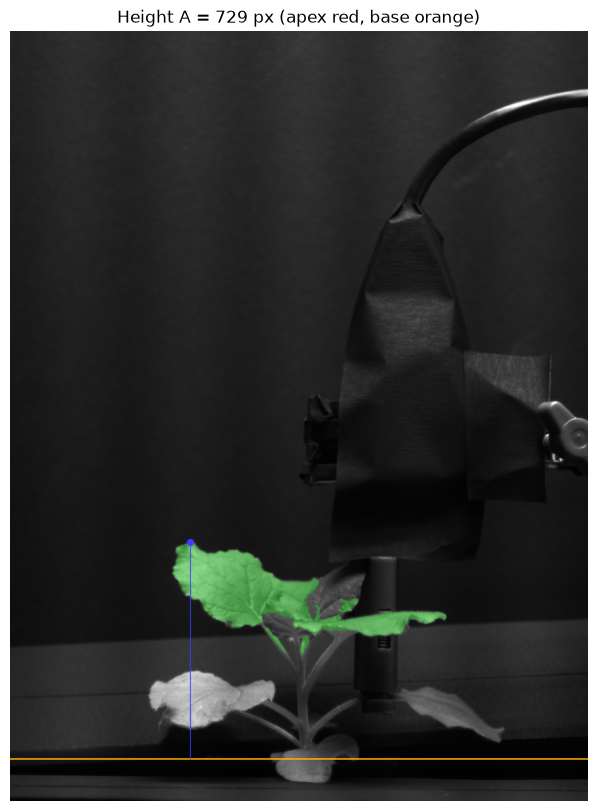

In [9]:
import heapq

def measure_height_vertical(mask, base_y):
    ys, xs = np.where(mask > 0)
    if ys.size == 0:
        return dict(height_px=0, apex_x=None, apex_y=None, area_px=0)
    apex_y = int(ys.min())
    apex_x = int(xs[np.argmin(ys)])
    return dict(height_px=int(base_y - apex_y), apex_x=apex_x, apex_y=apex_y, area_px=int(ys.size))

def _geodesic_length(skel_bool, src, dst):
    h, w = skel_bool.shape
    src = (int(src[0]), int(src[1])); dst = (int(dst[0]), int(dst[1]))
    dist = {src: 0.0}
    pq = [(0.0, src)]
    nbrs = [(-1,-1,2**0.5),(-1,0,1.0),(-1,1,2**0.5),(0,-1,1.0),
            (0,1,1.0),(1,-1,2**0.5),(1,0,1.0),(1,1,2**0.5)]
    while pq:
        d, (y, x) = heapq.heappop(pq)
        if (y, x) == dst:
            return float(d)
        if d > dist.get((y, x), 1e18):
            continue
        for dy, dx, wgt in nbrs:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and skel_bool[ny, nx]:
                nd = d + wgt
                if nd < dist.get((ny, nx), 1e18):
                    dist[(ny, nx)] = nd
                    heapq.heappush(pq, (nd, (ny, nx)))
    return float("nan")

def measure_height_skeleton(mask, base_y, prune_size=PRUNE_SIZE):
    try:
        skel = pcv.morphology.skeletonize(mask=(mask > 0).astype(np.uint8) * 255)
        pruned, _, _ = pcv.morphology.prune(skel_img=skel, size=prune_size)
        pts = np.argwhere(pruned > 0)  # (y, x)
        if pts.shape[0] < 2:
            return dict(stem_path_px=float("nan"), skel_px=int((pruned > 0).sum()))
        # Measure within the largest connected skeleton piece so a stray fragment near the base
        # can't make the base<->apex path unreachable.
        nb, lbl = cv2.connectedComponents((pruned > 0).astype(np.uint8), connectivity=8)
        sizes = np.bincount(lbl.ravel())
        main = int(np.argmax(sizes[1:])) + 1
        comp = lbl == main
        cpts = np.argwhere(comp)
        base_idx = int(np.argmin(np.abs(cpts[:, 0] - base_y)))
        apex_idx = int(np.argmin(cpts[:, 0]))
        length = _geodesic_length(comp, tuple(cpts[base_idx]), tuple(cpts[apex_idx]))
        return dict(stem_path_px=length, skel_px=int((pruned > 0).sum()))
    except Exception as e:
        return dict(stem_path_px=float("nan"), skel_px=0, skel_error=str(e))

def px_to_mm(v):
    if not PX_PER_MM or v is None:
        return None
    if isinstance(v, float) and np.isnan(v):
        return None
    return v / PX_PER_MM


res = dict(measure_height_vertical(mask_plant, base_y_used))
if MEASURE_SKELETON:
    res.update(measure_height_skeleton(mask_plant, base_y_used))

mm_A = px_to_mm(res["height_px"])
print(f"Height A (vertical): {res['height_px']} px" + (f"  = {mm_A:.2f} mm" if mm_A else ""))
if MEASURE_SKELETON:
    print(f"Height C (skeleton path): {res.get('stem_path_px')} px")

vis = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
vis[mask_plant > 0] = (0, 200, 0)
vis = cv2.addWeighted(cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR), 0.6, vis, 0.4, 0)
cv2.line(vis, (0, base_y_used), (gray.shape[1], base_y_used), (0, 180, 255), 3)
if res["apex_x"] is not None:
    cv2.circle(vis, (res["apex_x"], res["apex_y"]), 12, (0, 0, 255), -1)
    cv2.line(vis, (res["apex_x"], res["apex_y"]), (res["apex_x"], base_y_used), (0, 0, 255), 2)

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title(f"Height A = {res['height_px']} px (apex red, base orange)"); ax.axis("off")
plt.show()

## Stage 4 - Batch over the selected subset

Processes `subset_paths` (every `FRAME_STEP`th frame) with the tuned parameters and writes to `plant_timelapse/outputs/<timelapse_name>/`:

- `mask/` binary masks and `overlay/` QC images (per frame),
- `heights.csv` (frame, timestamp, heights, area, flag),
- `growth_curve.png`.

Frames whose height deviates strongly from the rolling median are flagged `check`. Set `FRAME_STEP = 1` in Stage 0 for the full 325-frame run once the subset looks right.

In [ ]:
# --- Stage 4 params (edit here) ---
OUTPUT_ROOT = REPO_ROOT / "plant_timelapse" / "outputs" / TIMELAPSE_DIR.name
SAVE_MASKS = True
SAVE_OVERLAYS = True
JUMP_FLAG_FACTOR = 3.0   # flag frame if |height - median| > factor * (scaled MAD)

In [ ]:
import csv

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
mask_dir = OUTPUT_ROOT / "mask"
overlay_dir = OUTPUT_ROOT / "overlay"
if SAVE_MASKS: mask_dir.mkdir(exist_ok=True)
if SAVE_OVERLAYS: overlay_dir.mkdir(exist_ok=True)

rows = []
for i, p in enumerate(subset_paths):
    idx = all_paths.index(p)
    g = load_gray(p); g8 = to_u8(g)
    m, by, thr = segment_plant(g, hardware_mask=hardware_mask, roi=ROI, base_y=BASE_LINE_Y)
    r = measure_height_vertical(m, by)
    if MEASURE_SKELETON:
        r.update(measure_height_skeleton(m, by))
    ts = timestamps[idx]
    rows.append(dict(frame_index=idx, file=p.name, timestamp=ts.isoformat() if ts else "",
                     threshold=thr, base_y=by, **r))
    if SAVE_MASKS:
        cv2.imwrite(str(mask_dir / (p.stem + ".png")), m)
    if SAVE_OVERLAYS:
        ov = cv2.cvtColor(g8, cv2.COLOR_GRAY2BGR); ov[m > 0] = (0, 200, 0)
        ov = cv2.addWeighted(cv2.cvtColor(g8, cv2.COLOR_GRAY2BGR), 0.6, ov, 0.4, 0)
        cv2.line(ov, (0, by), (g.shape[1], by), (0, 180, 255), 2)
        if r["apex_x"] is not None:
            cv2.circle(ov, (r["apex_x"], r["apex_y"]), 10, (0, 0, 255), -1)
        cv2.imwrite(str(overlay_dir / (p.stem + ".png")), ov)
    if (i + 1) % 10 == 0 or i == len(subset_paths) - 1:
        print(f"  {i + 1}/{len(subset_paths)} processed")

heights = np.array([r["height_px"] for r in rows], float)
med = np.median(heights)
mad = np.median(np.abs(heights - med)) + 1e-9
for r, hgt in zip(rows, heights):
    r["flag"] = "check" if abs(hgt - med) > JUMP_FLAG_FACTOR * 1.4826 * mad else ""

csv_path = OUTPUT_ROOT / "heights.csv"
fields = ["frame_index", "file", "timestamp", "threshold", "base_y", "height_px",
          "apex_x", "apex_y", "area_px", "stem_path_px", "skel_px", "flag"]
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fields, extrasaction="ignore")
    w.writeheader(); w.writerows(rows)
print("wrote", csv_path)

ts_list = [timestamps[r["frame_index"]] for r in rows]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ts_list, heights, "-o", ms=3, label="Height A (px)")
if MEASURE_SKELETON:
    sp = np.array([r.get("stem_path_px", float("nan")) for r in rows], float)
    ax.plot(ts_list, sp, "-s", ms=3, alpha=0.7, label="Stem path C (px)")
flagged = [(t, h) for t, h, r in zip(ts_list, heights, rows) if r["flag"]]
if flagged:
    ax.scatter([t for t, _ in flagged], [h for _, h in flagged],
               c="red", zorder=5, label="flagged")
ax.set_xlabel("time"); ax.set_ylabel("height (px)")
ax.set_title("Plant growth curve"); ax.legend()
fig.autofmt_xdate(); plt.tight_layout()
fig.savefig(OUTPUT_ROOT / "growth_curve.png", dpi=120)
plt.show()
print("done ->", OUTPUT_ROOT)
print("flagged frames:", sum(1 for r in rows if r["flag"]))